In [67]:
import kagglehub

In [ ]:
path = kagglehub.dataset_download("gpreda/chinese-mnist")
print("Path to dataset files:", path)

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from PIL import Image
import os
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
# print(os.cpu_count())

In [72]:
os.chdir(path)

In [73]:
# this class construction codes are obtained from https://www.kaggle.com/code/tomasrando/perceptron-multicapa-con-dropout
# thank Tomas Rando for sharing his work
from torch.utils.data import Dataset, DataLoader

class ChineseNumbersDataset(Dataset):
    def __init__(self, data, img_dir, transform=None):
        self.data = data
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        img_name = f"input_{row['suite_id']}_{row['sample_id']}_{row['code']}.jpg"
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        if self.transform: 
            image = self.transform(image)

        label = int(row['code']) - 1

        return image, label

import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),        # a tensor
    # transforms.Normalize((0.5,), (0.5,)) # normalizar
])

In [74]:
!pwd # make sure at the dataset location
df = pd.read_csv("chinese_mnist.csv")
print("\n Snip \n")
print(df.head())
print("\n Description \n")
print(df.info())
print("\n CLASSES \n")
print(df['value'].unique())

dataset = ChineseNumbersDataset(df, "data/data/", transform = transform)

/home/jfongng/.cache/kagglehub/datasets/gpreda/chinese-mnist/versions/7

 Snip 

   suite_id  sample_id  code  value character
0         1          1    10      9         九
1         1         10    10      9         九
2         1          2    10      9         九
3         1          3    10      9         九
4         1          4    10      9         九

 Description 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   suite_id   15000 non-null  int64 
 1   sample_id  15000 non-null  int64 
 2   code       15000 non-null  int64 
 3   value      15000 non-null  int64 
 4   character  15000 non-null  object
dtypes: int64(4), object(1)
memory usage: 586.1+ KB
None

 CLASSES 

[        9        10       100      1000     10000 100000000         0
         1         2         3         4         5         6         7
         8]


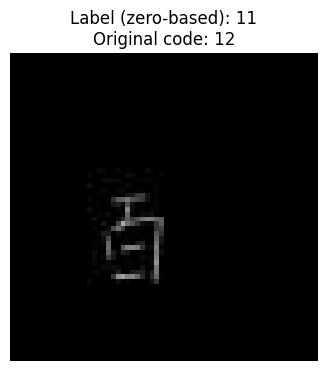

In [75]:
import matplotlib.pyplot as plt
import torch

# pick any index you want to inspect
idx = 2957

image_tensor, label_tensor = dataset[idx]  # <-- uses __getitem__
label = label_tensor
img = image_tensor.clone()

if image_tensor.ndim == 3:
    # img = img * std[:, None, None] + mean[:, None, None]  # unnormalize
    img = img.permute(1, 2, 0).cpu().numpy()  # (H, W, C)
# else:
    # raise ValueError("Expected a 3D tensor (C, H, W)")

plt.figure(figsize=(4, 4))
plt.imshow(img.clip(0, 1))  # clip in case of slight float errors
plt.axis("off")
plt.title(f"Label (zero-based): {label}\nOriginal code: {label + 1}")
plt.show()

In [76]:
df[(df['suite_id'] == 20) & (df['sample_id'] == 4)]

,suite_id,sample_id,code,value,character
134,20,4,10,9,九
1134,20,4,11,10,十
2134,20,4,12,100,百
3134,20,4,13,1000,千
4134,20,4,14,10000,万
5134,20,4,15,100000000,亿
6134,20,4,1,0,零
7134,20,4,2,1,一
8134,20,4,3,2,二
9134,20,4,4,3,三
